In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display, Markdown
from openpyxl import load_workbook

DESKTOP = Path.home() / "Desktop"
SOURCE_XLSX = DESKTOP / "PE6201_A2_Cost_Model.xlsx"

# Keep all generated outputs together on the Desktop.
OUTPUT_DIR = DESKTOP / "PE6201_A2_Cost_Visualisation_Output"
FIGURE_DIR = OUTPUT_DIR / "figures"
DATA_DIR = OUTPUT_DIR / "data_exports"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

if not SOURCE_XLSX.exists():
    raise FileNotFoundError(f"Source workbook not found: {SOURCE_XLSX}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 220,
    "savefig.bbox": "tight",
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "PingFang SC", "DejaVu Sans"],
    "axes.titleweight": "bold",
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

BLUE = "#4472C4"
LIGHT_BLUE = "#A9C4EB"
ORANGE = "#ED7D31"
GOLD = "#D6A84B"
OLIVE = "#7E9E55"
DARK = "#263238"
GREY = "#A7A9AC"
LIGHT_GREY = "#E7E9EC"

print(f"Source workbook: {SOURCE_XLSX}")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.Source workbook: /Users/hanhaochen/Desktop/PE6201_A2_Cost_Model.xlsx



## Data

The workbook already contains calculated values and cached formula results. The cells below read only the fields used in the visualisations, preserving the workbook as the traceable source.

In [10]:
wb = load_workbook(SOURCE_XLSX, data_only=True, read_only=True)
ws_cost = wb["Cost Model"]
ws_sens = wb["Sensitivity"]
ws_inputs = wb["Inputs"]

def find_input_row(label, search_columns=(1, 2)):
    # Find a row by its text label so the notebook survives inserted rows.
    target = label.strip().casefold()
    for row_number in range(1, ws_inputs.max_row + 1):
        for column_number in search_columns:
            value = ws_inputs.cell(row_number, column_number).value
            if isinstance(value, str) and value.strip().casefold() == target:
                return row_number
    raise KeyError(f"Could not find '{label}' in the Inputs sheet")

def input_value(label):
    return ws_inputs.cell(find_input_row(label), 3).value

def comparison_values(label):
    row_number = find_input_row(label, search_columns=(1,))
    return ws_inputs.cell(row_number, 2).value, ws_inputs.cell(row_number, 3).value

cost_rows = [5, 6, 7, 8]
baseline = pd.DataFrame({
    "model": [ws_cost[f"A{r}"].value for r in cost_rows],
    "monthly_api": [ws_cost[f"O{r}"].value for r in cost_rows],
    "monthly_fallback": [ws_cost[f"P{r}"].value for r in cost_rows],
    "monthly_fixed": [ws_cost[f"Q{r}"].value for r in cost_rows],
    "monthly_total": [ws_cost[f"R{r}"].value for r in cost_rows],
    "success_rate": [ws_cost[f"I{r}"].value for r in cost_rows],
})

scenario_rows = {
    "Gemma 3 27B": (5, 7, 9),
    "Mistral Medium 3.5": (10, 12, 14),
    "GPT-4o-mini": (15, 17, 19),
    "Qwen3.8 Flash": (20, 22, 24),
}
scenario_records = []
for model, (down_row, base_row, up_row) in scenario_rows.items():
    scenario_records.extend([
        {"model": model, "scenario": "Downside −10pp", "monthly_cost": ws_sens[f"J{down_row}"].value},
        {"model": model, "scenario": "Base", "monthly_cost": ws_sens[f"J{base_row}"].value},
        {"model": model, "scenario": "Upside +10pp", "monthly_cost": ws_sens[f"J{up_row}"].value},
    ])
sensitivity = pd.DataFrame(scenario_records)

sequential_turns, parallel_turns = comparison_values("Median turns")
sequential_tokens, parallel_tokens = comparison_values("Total input tokens")
sequential_cost, parallel_cost = comparison_values("Total recorded cost")

efficiency = pd.DataFrame({
    "metric": ["Median turns", "Input tokens", "Recorded model cost"],
    "sequential_value": [sequential_turns, sequential_tokens, sequential_cost],
    "parallel_value": [parallel_turns, parallel_tokens, parallel_cost],
})
efficiency["sequential_index"] = 100.0
efficiency["parallel_index"] = efficiency["parallel_value"] / efficiency["sequential_value"] * 100
efficiency["reduction"] = 1 - efficiency["parallel_value"] / efficiency["sequential_value"]

monthly_claims = input_value("Monthly claims")
fallback_cost = input_value("Failure cost per claim")
fixed_monthly_cost = input_value("Total fixed monthly cost")

baseline.to_csv(DATA_DIR / "baseline_monthly_costs.csv", index=False)
sensitivity.to_csv(DATA_DIR / "sensitivity_scenarios.csv", index=False)
efficiency.to_csv(DATA_DIR / "efficiency_index.csv", index=False)

display(baseline.style.format({
    "monthly_api": "${:,.2f}",
    "monthly_fallback": "${:,.2f}",
    "monthly_fixed": "${:,.2f}",
    "monthly_total": "${:,.2f}",
    "success_rate": "{:.1%}",
}))

,model,monthly_api,monthly_fallback,monthly_fixed,monthly_total,success_rate
0,Gemma 3 27B,$5.77,"$25,158.62",$429.00,"$25,593.39",0.0%
1,Mistral Medium 3.5,$117.45,"$28,303.45",$429.00,"$28,849.89",0.0%
2,GPT-4o-mini,$10.31,"$25,158.62",$429.00,"$25,597.93",0.0%
3,Qwen3.8 Flash,$17.85,"$30,400.00",$429.00,"$30,846.85",0.0%


In [4]:
# Reconciliation checks before charting
component_total = baseline[["monthly_api", "monthly_fallback", "monthly_fixed"]].sum(axis=1)
assert np.allclose(component_total, baseline["monthly_total"], atol=0.01)
assert monthly_claims == 8000
assert np.isclose(fallback_cost, 7.60)
assert np.isclose(fixed_monthly_cost, 429.00)

baseline_gap = baseline.set_index("model").loc["GPT-4o-mini", "monthly_total"] - baseline.set_index("model").loc["Gemma 3 27B", "monthly_total"]
one_pp_value = monthly_claims * 0.01 * fallback_cost
ten_pp_value = 10 * one_pp_value

print(f"Component reconciliation: passed for {len(baseline)} models")
print(f"Gemma vs GPT-4o-mini difference: ${baseline_gap:,.2f}/month")
print(f"Cost impact of +1pp success: ${one_pp_value:,.0f}/month")
print(f"Cost impact of +10pp success: ${ten_pp_value:,.0f}/month")

Component reconciliation: passed for 4 models
Gemma vs GPT-4o-mini difference: $4.54/month
Cost impact of +1pp success: $608/month
Cost impact of +10pp success: $6,080/month


## Results

### 1. Baseline monthly cost by model

The chart is sorted from lowest to highest and uses direct value labels. The x-axis starts at zero so the absolute magnitude is not exaggerated.

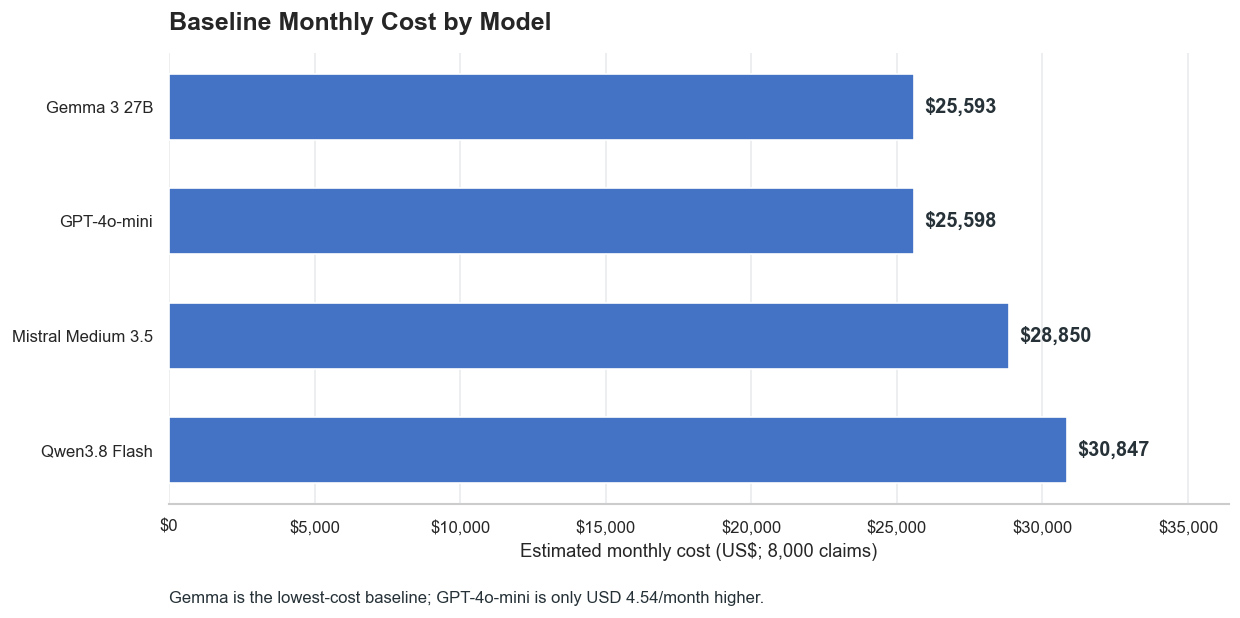

In [5]:
plot_data = baseline.sort_values("monthly_total", ascending=True).copy()

fig, ax = plt.subplots(figsize=(10.5, 5.4))
bars = ax.barh(plot_data["model"], plot_data["monthly_total"], color=BLUE, height=0.58)
ax.set_title("Baseline Monthly Cost by Model", loc="left", pad=14)
ax.set_xlabel("Estimated monthly cost (US$; 8,000 claims)")
ax.set_ylabel("")
ax.set_xlim(0, plot_data["monthly_total"].max() * 1.18)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.grid(axis="x", color=LIGHT_GREY, linewidth=0.9)
ax.grid(axis="y", visible=False)
ax.spines[["top", "right", "left"]].set_visible(False)

for bar, value in zip(bars, plot_data["monthly_total"]):
    ax.text(value + 350, bar.get_y() + bar.get_height()/2, f"${value:,.0f}", va="center", color=DARK, fontweight="bold")

ax.text(0, -0.22, f"Gemma is the lowest-cost baseline; GPT-4o-mini is only USD {baseline_gap:,.2f}/month higher.",
        transform=ax.transAxes, fontsize=10, color=DARK)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_baseline_monthly_cost.png")
plt.show()

**Interpretation.** Gemma and GPT-4o-mini are effectively tied on monthly cost. Mistral and Qwen are more expensive mainly because the model's measured success rate changes expected fallback expenditure; direct model cost is too small to explain the gap.

### 2. Cost composition of the lowest-cost model

A 100% stacked bar is used instead of a pie chart because aligned length makes the share comparison easier. Exact amounts and shares remain visible even when a component is too small to draw clearly.

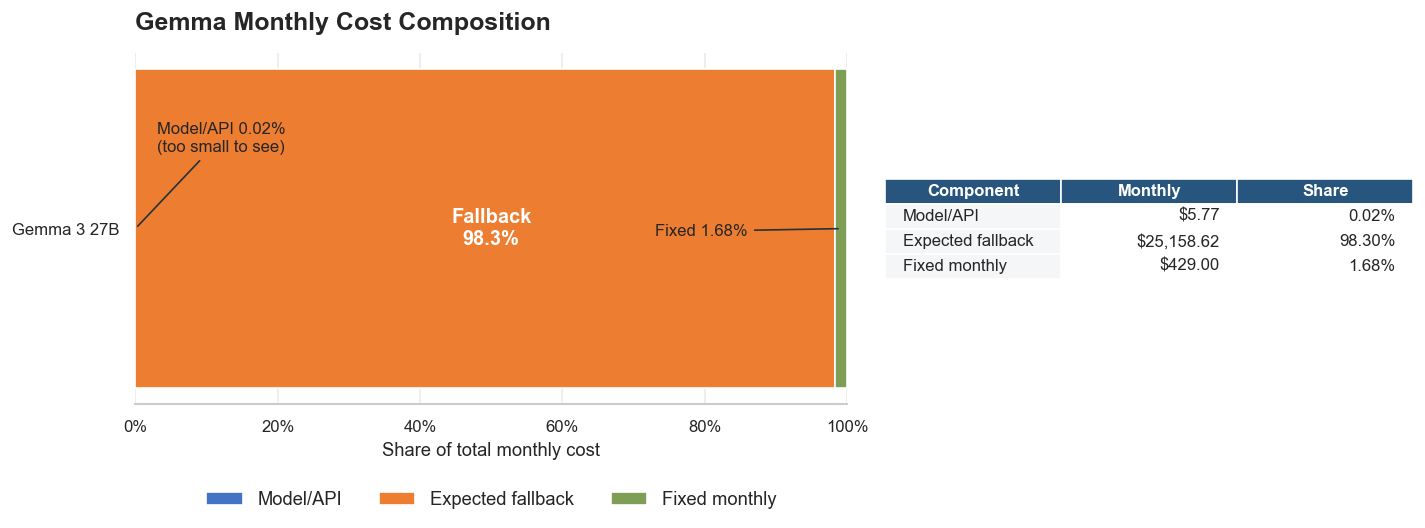

In [6]:
gemma = baseline.set_index("model").loc["Gemma 3 27B"]
mix = pd.DataFrame({
    "component": ["Model/API", "Expected fallback", "Fixed monthly"],
    "amount": [gemma["monthly_api"], gemma["monthly_fallback"], gemma["monthly_fixed"]],
})
mix["share"] = mix["amount"] / mix["amount"].sum()
mix.to_csv(DATA_DIR / "gemma_cost_mix.csv", index=False)

fig, (ax, ax_table) = plt.subplots(1, 2, figsize=(12, 4.7), gridspec_kw={"width_ratios": [1.55, 1]})
left = 0
colors = [BLUE, ORANGE, OLIVE]
for (_, row), color in zip(mix.iterrows(), colors):
    ax.barh(["Gemma 3 27B"], [row["share"]], left=left, color=color, height=0.42, label=row["component"])
    left += row["share"]

ax.set_title("Gemma Monthly Cost Composition", loc="left", pad=14)
ax.set_xlabel("Share of total monthly cost")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlim(0, 1)
ax.grid(axis="x", color=LIGHT_GREY, linewidth=0.9)
ax.grid(axis="y", visible=False)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.20), ncol=3, frameon=False)
ax.text(0.50, 0, f"Fallback\n{mix.loc[1, 'share']:.1%}", ha="center", va="center", color="white", fontweight="bold", fontsize=12)
ax.annotate(f"Fixed {mix.loc[2, 'share']:.2%}", xy=(0.992, 0), xytext=(0.73, 0.48),
            textcoords="axes fraction", arrowprops={"arrowstyle": "-", "color": DARK}, fontsize=10)
ax.annotate(f"Model/API {mix.loc[0, 'share']:.2%}\n(too small to see)", xy=(0.0001, 0), xytext=(0.03, 0.72),
            textcoords="axes fraction", arrowprops={"arrowstyle": "-", "color": DARK}, fontsize=10)

ax_table.axis("off")
table_rows = [[row.component, f"${row.amount:,.2f}", f"{row.share:.2%}"] for row in mix.itertuples()]
table = ax_table.table(cellText=table_rows, colLabels=["Component", "Monthly", "Share"], loc="center", cellLoc="right")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.15, 1.55)
for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor("white")
    if r == 0:
        cell.set_facecolor("#27557D")
        cell.set_text_props(color="white", weight="bold")
    elif c == 0:
        cell.set_text_props(ha="left")
        cell.set_facecolor("#F4F6F8")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_gemma_cost_composition.png")
plt.show()

**Interpretation.** Expected fallback accounts for 98.30% of Gemma's monthly cost, compared with 1.68% fixed cost and 0.02% model/API cost. Small token-price reductions therefore have little influence on total expenditure unless they also improve task success.

### 3. Success-rate sensitivity

The bars show three discrete scenarios for every model using a common dollar scale. They are operational scenarios—not statistical uncertainty intervals.

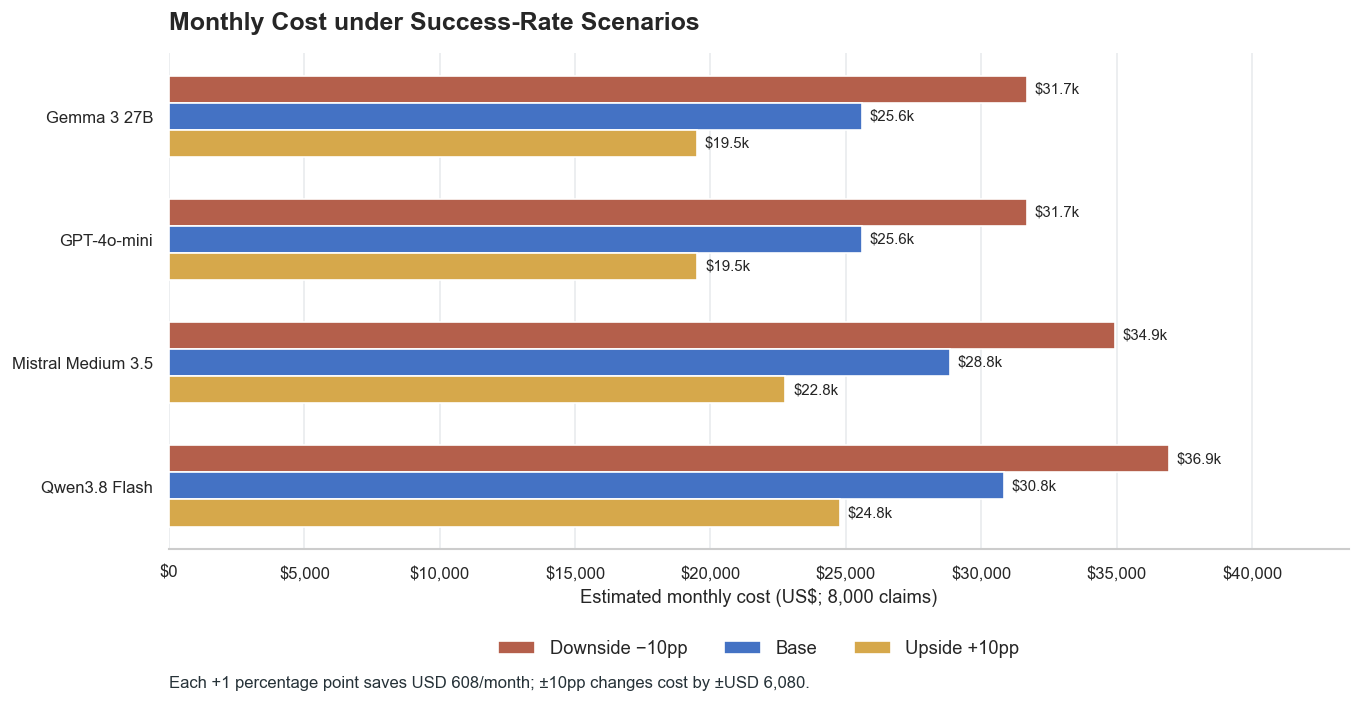

In [7]:
scenario_order = ["Downside −10pp", "Base", "Upside +10pp"]
model_order = baseline.sort_values("monthly_total")["model"].tolist()
palette = {"Downside −10pp": "#B45F4B", "Base": BLUE, "Upside +10pp": GOLD}

fig, ax = plt.subplots(figsize=(11.5, 6.2))
y = np.arange(len(model_order))
height = 0.22
offsets = [-height, 0, height]

for scenario, offset in zip(scenario_order, offsets):
    values = (sensitivity[sensitivity["scenario"] == scenario]
              .set_index("model").loc[model_order, "monthly_cost"])
    bars = ax.barh(y + offset, values, height=height, color=palette[scenario], label=scenario)
    for bar, value in zip(bars, values):
        ax.text(value + 280, bar.get_y() + bar.get_height()/2, f"${value/1000:.1f}k", va="center", fontsize=9)

ax.set_yticks(y, model_order)
ax.invert_yaxis()
ax.set_title("Monthly Cost under Success-Rate Scenarios", loc="left", pad=14)
ax.set_xlabel("Estimated monthly cost (US$; 8,000 claims)")
ax.set_ylabel("")
ax.set_xlim(0, sensitivity["monthly_cost"].max() * 1.18)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.grid(axis="x", color=LIGHT_GREY, linewidth=0.9)
ax.grid(axis="y", visible=False)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
ax.text(0, -0.28, f"Each +1 percentage point saves USD {one_pp_value:,.0f}/month; ±10pp changes cost by ±USD {ten_pp_value:,.0f}.",
        transform=ax.transAxes, fontsize=10, color=DARK)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_success_rate_sensitivity.png")
plt.show()

**Interpretation.** All models move by the same US$6,080 for a ±10 percentage-point scenario because monthly volume and fallback cost are shared assumptions. This confirms that success rate is the dominant cost lever in the model.

### 4. Sequential versus parallel efficiency

A dumbbell chart shows the movement from the Sequential baseline (index = 100) to the Parallel result. Direct labels show the percentage reduction, so the comparison does not depend on color alone.

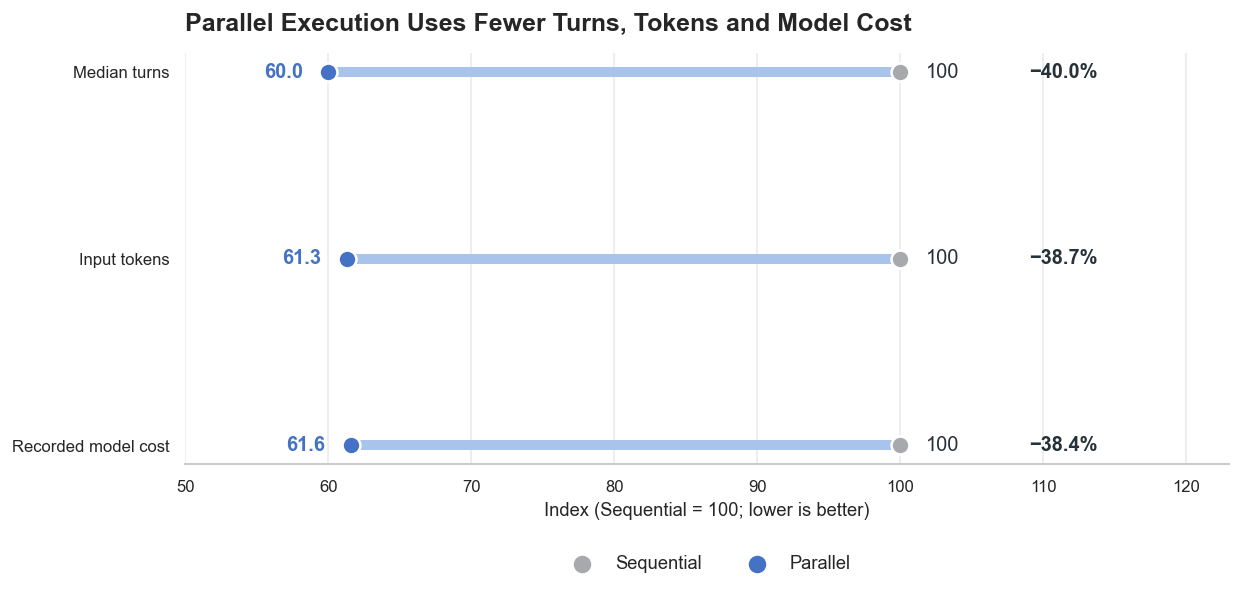

In [8]:
eff_plot = efficiency.iloc[::-1].reset_index(drop=True)
y = np.arange(len(eff_plot))

fig, ax = plt.subplots(figsize=(10.5, 5.2))
for i, row in eff_plot.iterrows():
    ax.plot([row["parallel_index"], row["sequential_index"]], [i, i], color=LIGHT_BLUE, linewidth=6, solid_capstyle="round")
    ax.scatter(row["sequential_index"], i, s=115, color=GREY, edgecolor="white", linewidth=1.5, zorder=3)
    ax.scatter(row["parallel_index"], i, s=115, color=BLUE, edgecolor="white", linewidth=1.5, zorder=3)
    ax.text(row["parallel_index"] - 1.8, i, f"{row['parallel_index']:.1f}", ha="right", va="center", color=BLUE, fontweight="bold")
    ax.text(row["sequential_index"] + 1.8, i, "100", ha="left", va="center", color=DARK)
    ax.text(109, i, f"−{row['reduction']:.1%}", ha="left", va="center", color=DARK, fontweight="bold")

ax.set_yticks(y, eff_plot["metric"])
ax.set_xlim(50, 123)
ax.set_xlabel("Index (Sequential = 100; lower is better)")
ax.set_ylabel("")
ax.set_title("Parallel Execution Uses Fewer Turns, Tokens and Model Cost", loc="left", pad=14)
ax.grid(axis="x", color=LIGHT_GREY, linewidth=0.9)
ax.grid(axis="y", visible=False)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.scatter([], [], s=90, color=GREY, label="Sequential")
ax.scatter([], [], s=90, color=BLUE, label="Parallel")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_parallel_efficiency.png")
plt.show()

**Interpretation.** Parallel execution reduces median turns from five to three, input tokens from 550,849 to 337,806, and recorded model cost from US$0.0653 to US$0.0402 in the 33-trial comparison. This supports parallel tool execution as the clearest direct model-cost lever.

## Takeaways

1. **Baseline choice:** Gemma is the lowest-cost baseline, although GPT-4o-mini is effectively tied and should not be described as meaningfully more expensive without considering quality and operational factors.
2. **Primary cost driver:** Expected fallback dominates the monthly cost model. Success-rate improvement is much more important than small token-price differences.
3. **Operational design:** Parallel execution is supported by the measured reductions in turns, input tokens and recorded model cost.
4. **Important caveat:** The success-rate sensitivity chart is scenario analysis. It shows the financial consequence of changed performance, not evidence that the models will actually gain or lose ten percentage points.

### Exported outputs

- `figures/01_baseline_monthly_cost.png`
- `figures/02_gemma_cost_composition.png`
- `figures/03_success_rate_sensitivity.png`
- `figures/04_parallel_efficiency.png`
- `data_exports/*.csv`

Source workbook: `~/Desktop/PE6201_A2_Cost_Model.xlsx`